#**IMPORT LIBRARIES**

In [ ]:
import warnings
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split,StratifiedKFold,cross_validate)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (OneHotEncoder,StandardScaler)
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix,ConfusionMatrixDisplay,precision_recall_curve,roc_curve)
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")
print("Week 6 libraries imported successfully.")


Week 6 libraries imported successfully.


#**LOADING DATASETS**

In [ ]:
health_connect_clean = pd.read_csv('HealthConnect_Week5_Cleaned_Model_Dataset.csv')
health_connect_ml_ready = pd.read_csv('HealthConnect_ML_Ready_Dataset.csv')
health_connect_feature_doc = pd.read_csv('HealthConnect_Feature_Documentation.csv')
health_connect_baseline_results = pd.read_csv('HealthConnect_Baseline_Model_Results.csv')
print("Week 5 ML-ready dataset loaded successfully.")
print("Dataset shape:",health_connect_ml_ready.shape)
display(health_connect_ml_ready.head())

Week 5 ML-ready dataset loaded successfully.
Dataset shape: (4737, 5)


,Unnamed: 0,previous_no_shows,waiting_time_minutes,appointment_day,no_show
0,0,0,29.0,Tuesday,1
1,1,0,42.0,Friday,0
2,2,1,11.0,Wednesday,1
3,3,1,35.0,Thursday,0
4,4,1,27.0,Monday,1


#**IDENTIFY TARGET AND FEATURES**

In [ ]:
TARGET = "no_show"
if TARGET not in health_connect_ml_ready.columns:
    raise KeyError("The Week 5 ML-ready dataset does not contain ""'no_show'.")
feature_columns = [column
    for column in health_connect_ml_ready.columns
    if column != TARGET]
X = health_connect_ml_ready[feature_columns].copy()
y = health_connect_ml_ready[TARGET].copy()
print("Target:", TARGET)
print("Number of Week 5 features:", len(feature_columns))
print("Features:")
for feature in feature_columns:
    print("-", feature)
print("\nTarget distribution:")
display(y.value_counts().rename(index={0: "Attended",1: "No-Show"}).to_frame("Count"))

Target: no_show
Number of Week 5 features: 4
Features:
- Unnamed: 0
- previous_no_shows
- waiting_time_minutes
- appointment_day

Target distribution:


,Count
no_show,
No-Show,2423
Attended,2314


#**RECREATE WEEK 5 BASELINE PIPELINE**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
numeric_features = (X_train.select_dtypes(include=np.number).columns.tolist())
categorical_features = (X_train.select_dtypes(include=["object","category","bool","string"]).columns.tolist())
numeric_transformer = Pipeline(steps=[("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
categorical_transformer = Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(handle_unknown="ignore",sparse_output=False))])
preprocessor = ColumnTransformer(transformers=[("numeric",numeric_transformer,numeric_features),("categorical",categorical_transformer,categorical_features)],remainder="drop")
baseline_model = Pipeline(steps=[("preprocessor",preprocessor),("classifier",LogisticRegression( max_iter=1000,random_state=42))])
baseline_model.fit(X_train,y_train)
baseline_predictions = baseline_model.predict(X_test)
baseline_probabilities = (baseline_model.predict_proba(X_test)[:, 1])
print("Week 5 baseline Logistic Regression recreated.")

Week 5 baseline Logistic Regression recreated.


#**BASELINE METRICS**

In [ ]:
baseline_metrics = {"Model": "Week 5 Logistic Regression","Accuracy": accuracy_score(y_test,baseline_predictions),"Precision": precision_score(y_test,baseline_predictions,zero_division=0),"Recall": recall_score(y_test,baseline_predictions,zero_division=0),"F1 Score": f1_score(y_test,baseline_predictions,zero_division=0),"ROC-AUC": roc_auc_score(y_test,baseline_probabilities)}
baseline_results = pd.DataFrame([baseline_metrics])
display(baseline_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Week 5 Logistic Regression,0.5295,0.5436,0.501,0.5215,0.5434


#**BASELINE CLASSIFICATION REPORT**

In [ ]:
print(classification_report(y_test,baseline_predictions,target_names=["Attended","No-Show"],zero_division=0))

              precision    recall  f1-score   support

    Attended       0.52      0.56      0.54       463
     No-Show       0.54      0.50      0.52       485

    accuracy                           0.53       948
   macro avg       0.53      0.53      0.53       948
weighted avg       0.53      0.53      0.53       948



#**BASELINE CONFUSION MATRIX**

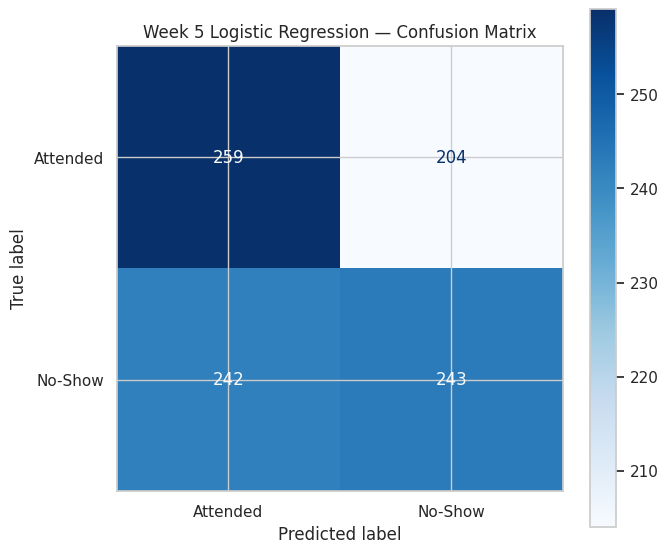

In [ ]:
baseline_cm = confusion_matrix(y_test,baseline_predictions)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=baseline_cm,display_labels=["Attended","No-Show"]).plot(ax=ax,cmap="Blues")
plt.title("Week 5 Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

#**CREATE ERROR-ANALYSIS DATASET**

In [ ]:
error_analysis = X_test.copy()
error_analysis["actual_no_show"] = y_test.values
error_analysis["predicted_no_show"] = baseline_predictions
error_analysis["predicted_probability"] = (baseline_probabilities)
def classify_prediction(row):
    actual = row["actual_no_show"]
    predicted = row["predicted_no_show"]
    if actual == 1 and predicted == 1:
        return "True Positive"
    if actual == 0 and predicted == 0:
        return "True Negative"
    if actual == 0 and predicted == 1:
        return "False Positive"
    return "False Negative"
error_analysis["prediction_type"] = (error_analysis.apply(classify_prediction,axis=1))
print("Error-analysis records:")
display(error_analysis["prediction_type"].value_counts().to_frame("Count"))

Error-analysis records:


,Count
prediction_type,
True Negative,259
True Positive,243
False Negative,242
False Positive,204


#**ERROR DISTRIBUTION**

In [ ]:
error_summary = (error_analysis["prediction_type"].value_counts().to_frame("Count"))
error_summary["Percentage"] = (error_summary["Count"]/ len(error_analysis)* 100).round(2)
display(error_summary)

,Count,Percentage
prediction_type,,
True Negative,259,27.32
True Positive,243,25.63
False Negative,242,25.53
False Positive,204,21.52


#**FALSE POSITIVE AND FALSE NEGATIVE RECORDS**

In [ ]:
false_positives = error_analysis[error_analysis["prediction_type"]== "False Positive"].copy()
false_negatives = error_analysis[error_analysis["prediction_type"]== "False Negative"].copy()
print("False positives:",len(false_positives))
print("False negatives:",len(false_negatives))
print("\nFalse-positive examples:")
display(false_positives.head(10))
print("\nFalse-negative examples:")
display(false_negatives.head(10))

False positives: 204
False negatives: 242

False-positive examples:


,Unnamed: 0,previous_no_shows,waiting_time_minutes,appointment_day,actual_no_show,predicted_no_show,predicted_probability,prediction_type
4239,4473,0,31.0,Sunday,0,1,0.510572,False Positive
3633,3839,1,2.0,Friday,0,1,0.544117,False Positive
4628,4883,1,19.0,Saturday,0,1,0.553995,False Positive
4386,4626,1,26.0,Thursday,0,1,0.568385,False Positive
3185,3366,2,32.0,Saturday,0,1,0.626701,False Positive
3919,4139,1,2.0,Friday,0,1,0.546122,False Positive
4104,4333,0,35.0,Sunday,0,1,0.507639,False Positive
933,994,2,10.0,Friday,0,1,0.611196,False Positive
2270,2392,1,35.0,Wednesday,0,1,0.560700,False Positive
3091,3266,3,4.0,Sunday,0,1,0.762704,False Positive



False-negative examples:


,Unnamed: 0,previous_no_shows,waiting_time_minutes,appointment_day,actual_no_show,predicted_no_show,predicted_probability,prediction_type
2680,2832,0,21.0,Friday,1,0,0.436335,False Negative
1005,1071,0,12.0,Friday,1,0,0.429080,False Negative
907,968,0,19.0,Monday,1,0,0.458170,False Negative
675,725,0,13.0,Wednesday,1,0,0.468748,False Negative
438,472,0,24.0,Sunday,1,0,0.487098,False Negative
3233,3416,0,21.0,Wednesday,1,0,0.482867,False Negative
2787,2946,0,37.0,Tuesday,1,0,0.449238,False Negative
3598,3800,0,29.0,Wednesday,1,0,0.481476,False Negative
4240,4474,0,10.0,Friday,1,0,0.452667,False Negative
3163,3343,0,31.0,Thursday,1,0,0.465731,False Negative


#**ERROR ANALYSIS BY AVAILABLE NUMERICAL FEATURES**

In [ ]:
error_numeric_features = [column for column in feature_columns if column in error_analysis.columns and pd.api.types.is_numeric_dtype(error_analysis[column])]
if error_numeric_features:
    error_numeric_summary = (error_analysis.groupby("prediction_type")[error_numeric_features].mean().round(2))
    print("Average numerical feature values by ""prediction type:")
    display(error_numeric_summary)

Average numerical feature values by prediction type:


,Unnamed: 0,previous_no_shows,waiting_time_minutes
prediction_type,,,
False Negative,2462.81,0.00,23.48
False Positive,2815.98,1.13,23.52
True Negative,2376.13,0.00,23.95
True Positive,2704.32,1.23,25.28


#**ERROR ANALYSIS BY AVAILABLE CATEGORICAL FEATURES**

In [ ]:
error_categorical_features = [column for column in feature_columns if column in error_analysis.columns and (error_analysis[column].dtype == "object"or str(error_analysis[column].dtype) in ["category", "string"])]
for column in error_categorical_features:
    print("\nError distribution by:",column)
    error_crosstab = pd.crosstab(error_analysis[column],error_analysis["prediction_type"],normalize="index").mul(100).round(2)
    display(error_crosstab)


Error distribution by: appointment_day


prediction_type,False Negative,False Positive,True Negative,True Positive
appointment_day,,,,
Friday,28.57,21.43,27.14,22.86
Monday,31.75,15.08,27.78,25.40
Saturday,28.46,20.77,27.69,23.08
Sunday,12.16,39.86,13.51,34.46
Thursday,29.41,18.49,28.57,23.53
Tuesday,19.70,18.18,37.12,25.00
Wednesday,30.07,15.03,30.72,24.18


#**WEEK 5 CLEANED DATASET**

In [ ]:
print("Full Week 5 cleaned dataset loaded.")
print("Shape:",health_connect_clean.shape)

Full Week 5 cleaned dataset loaded.
Shape: (4737, 23)


#**IDENTIFY POTENTIALLY USEFUL FEATURES**

In [ ]:
if health_connect_clean is not None:
    possible_features = ["previous_no_shows","waiting_time_minutes","appointment_day","appointment_date","appointment_time","reminder_sent","appointment_type","booking_lead_days","distance_to_clinic_km","age","gender"]
    leakage_keywords = ["outcome","status","attendance","attended","no_show","final","post"]
    refined_feature_candidates = []
    for column in possible_features:
        if column not in health_connect_clean.columns:
            continue
        normalized = (re.sub(r"[^a-z0-9]","",column.lower()))
        possible_leakage = any(keyword in normalized for keyword in leakage_keywords)
        if not possible_leakage:
            refined_feature_candidates.append(column)
    print("Potential refined features:")
    for feature in refined_feature_candidates:
        print("-", feature)
else:
    refined_feature_candidates = feature_columns.copy()

Potential refined features:
- previous_no_shows
- waiting_time_minutes
- appointment_day
- appointment_date
- appointment_time
- reminder_sent
- appointment_type
- booking_lead_days
- distance_to_clinic_km
- age
- gender


#**DEFINE REFINED FEATURES**

In [ ]:
refined_features = feature_columns.copy()
if health_connect_clean is not None:
    for feature in refined_feature_candidates:
        if feature not in refined_features:
            refined_features.append(feature)
refined_features = list(dict.fromkeys(refined_features))
print("Week 6 refined feature set:")
for number, feature in enumerate(refined_features,start=1):
    print(f"{number}. {feature}")
print("\nNumber of refined features:",len(refined_features))

Week 6 refined feature set:
1. Unnamed: 0
2. previous_no_shows
3. waiting_time_minutes
4. appointment_day
5. appointment_date
6. appointment_time
7. reminder_sent
8. appointment_type
9. booking_lead_days
10. distance_to_clinic_km
11. age
12. gender

Number of refined features: 12


#**BUILD REFINED DATASET**

In [ ]:
if health_connect_clean is not None:
    available_refined_features = [feature
        for feature in refined_features
        if feature in health_connect_clean.columns]
    refined_health_connect = health_connect_clean[available_refined_features + [TARGET]].copy()
else:
    available_refined_features = refined_features
    refined_health_connect = health_connect_ml_ready[available_refined_features + [TARGET]].copy()
print("Refined modelling dataset shape:",refined_health_connect.shape)
display(refined_health_connect.head())

Refined modelling dataset shape: (4737, 13)


,Unnamed: 0,previous_no_shows,waiting_time_minutes,appointment_day,appointment_date,appointment_time,reminder_sent,appointment_type,booking_lead_days,distance_to_clinic_km,age,gender,no_show
0,0,0,29.0,Tuesday,2025-02-18,Afternoon,Yes,Follow-up,12,19.3,39,Female,1
1,1,0,42.0,Friday,2026-02-27,Morning,Yes,Specialist Consultation,2,14.3,31,Male,0
2,2,1,11.0,Wednesday,2025-12-24,Morning,Yes,General Consultation,38,11.4,50,Female,1
3,3,1,35.0,Thursday,2025-08-28,Evening,Yes,Follow-up,41,7.4,59,Male,0
4,4,1,27.0,Monday,2025-08-25,Afternoon,Yes,Follow-up,47,5.6,34,Female,1


#**REFINED TRAIN/TEST SPLIT**

In [ ]:
X_refined = refined_health_connect[available_refined_features].copy()
y_refined = refined_health_connect[TARGET].copy()
X_train_r, X_test_r, y_train_r, y_test_r = (train_test_split(X_refined,y_refined,test_size=0.20,random_state=42,stratify=y_refined))
print("Refined training shape:",X_train_r.shape)
print("Refined testing shape:",X_test_r.shape)

Refined training shape: (3789, 12)
Refined testing shape: (948, 12)


#**CREATE REFINED PREPROCESSOR**

In [ ]:
numeric_features_r = (X_train_r.select_dtypes(include=np.number).columns.tolist())
categorical_features_r = (X_train_r.select_dtypes(include=["object","category","bool","string"]).columns.tolist())
numeric_transformer_r = Pipeline(steps=[("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
categorical_transformer_r = Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(handle_unknown="ignore",sparse_output=False))])
refined_preprocessor = ColumnTransformer(transformers=[("numeric",numeric_transformer_r,numeric_features_r),("categorical",categorical_transformer_r,categorical_features_r)],remainder="drop")
print("Refined preprocessing pipeline created.")

Refined preprocessing pipeline created.


#**IMPROVED LOGISTIC REGRESSION**

In [ ]:
improved_logistic = Pipeline(steps=[("preprocessor",refined_preprocessor),("classifier",LogisticRegression(max_iter=1500,class_weight="balanced",random_state=42))])
improved_logistic.fit(X_train_r,y_train_r)
improved_logistic_predictions = (improved_logistic.predict(X_test_r))
improved_logistic_probabilities = (improved_logistic.predict_proba(X_test_r)[:, 1])
print("Improved Logistic Regression trained.")

Improved Logistic Regression trained.


#**RANDOM FOREST**

In [ ]:
random_forest = Pipeline(steps=[("preprocessor",refined_preprocessor),("classifier",RandomForestClassifier(n_estimators=300,max_depth=None,min_samples_split=5,min_samples_leaf=2,class_weight="balanced",random_state=42,n_jobs=-1))])
random_forest.fit(X_train_r,y_train_r)
rf_predictions = (random_forest.predict(X_test_r))
rf_probabilities = (random_forest.predict_proba(X_test_r)[:, 1])
print("Random Forest model trained.")

Random Forest model trained.


#**MODEL EVALUATION FUNCTION**

In [ ]:
def calculate_metrics(model_name,y_true,predictions,probabilities):
    return {"Model": model_name,"Accuracy": accuracy_score(y_true,predictions),"Precision": precision_score(y_true,predictions,zero_division=0),"Recall": recall_score(y_true,predictions,zero_division=0),"F1 Score": f1_score(y_true,predictions,zero_division=0),"ROC-AUC": roc_auc_score(y_true,probabilities)}

#**MODEL COMPARISON**

In [ ]:
week6_model_results = pd.DataFrame([baseline_metrics,calculate_metrics("Week 6 Improved Logistic Regression",y_test_r,improved_logistic_predictions,improved_logistic_probabilities),calculate_metrics("Week 6 Random Forest",y_test_r,rf_predictions,rf_probabilities)])
display(week6_model_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Week 5 Logistic Regression,0.5295,0.5436,0.5010,0.5215,0.5434
1,Week 6 Improved Logistic Regression,0.6076,0.6084,0.6536,0.6302,0.6344
2,Week 6 Random Forest,0.6139,0.6146,0.6577,0.6355,0.6565


#**CROSS-VALIDATION**

In [ ]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scoring = {"accuracy": "accuracy","precision": "precision","recall": "recall","f1": "f1","roc_auc": "roc_auc"}
cv_models = {"Improved Logistic Regression":improved_logistic,"Random Forest":random_forest}
cv_results_list = []
for model_name, model in cv_models.items():
    scores = cross_validate(model,X_refined,y_refined,cv=cv,scoring=scoring,n_jobs=-1)
    cv_results_list.append({"Model": model_name,"CV Accuracy Mean":scores["test_accuracy"].mean(),"CV Accuracy Std":scores["test_accuracy"].std(),"CV Precision Mean":scores["test_precision"].mean(),"CV Recall Mean":scores["test_recall"].mean(),"CV F1 Mean":scores["test_f1"].mean(),"CV ROC-AUC Mean":scores["test_roc_auc"].mean(),"CV ROC-AUC Std":scores["test_roc_auc"].std()})
cv_results = pd.DataFrame(cv_results_list)
display(cv_results.round(4))

,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV ROC-AUC Mean,CV ROC-AUC Std
0,Improved Logistic Regression,0.6114,0.0060,0.6224,0.6117,0.6167,0.6470,0.0075
1,Random Forest,0.6295,0.0096,0.6419,0.6236,0.6325,0.6666,0.0109


#**THRESHOLD ANALYSIS FUNCTION**

In [ ]:
def threshold_analysis(y_true,probabilities):
    thresholds = np.arange(0.10,0.91,0.05)
    rows = []
    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)
        rows.append({"Threshold": round(threshold,2),"Precision": precision_score(y_true,predictions,zero_division=0),"Recall": recall_score(y_true,predictions,zero_division=0),"F1 Score": f1_score(y_true,predictions,zero_division=0),"Accuracy": accuracy_score(y_true,predictions),"No-Show Flags": predictions.sum()})
    return pd.DataFrame(rows)
threshold_logistic = threshold_analysis(y_test_r,improved_logistic_probabilities)
threshold_rf = threshold_analysis(y_test_r,rf_probabilities)
print("Improved Logistic Regression threshold analysis:")
display(threshold_logistic.round(4))
print("Random Forest threshold analysis:")
display(threshold_rf.round(4))

Improved Logistic Regression threshold analysis:


,Threshold,Precision,Recall,F1 Score,Accuracy,No-Show Flags
0,0.10,0.5127,0.9959,0.6769,0.5137,942
1,0.15,0.5183,0.9938,0.6813,0.5243,930
2,0.20,0.5199,0.9691,0.6767,0.5264,904
3,0.25,0.5290,0.9402,0.6771,0.5411,862
4,0.30,0.5460,0.9175,0.6846,0.5675,815
5,0.35,0.5563,0.8351,0.6678,0.5749,728
6,0.40,0.5627,0.7773,0.6528,0.5770,670
7,0.45,0.5835,0.7278,0.6477,0.5949,605
8,0.50,0.6084,0.6536,0.6302,0.6076,521
9,0.55,0.6380,0.5814,0.6084,0.6171,442


Random Forest threshold analysis:


,Threshold,Precision,Recall,F1 Score,Accuracy,No-Show Flags
0,0.10,0.5116,1.0000,0.6769,0.5116,948
1,0.15,0.5116,1.0000,0.6769,0.5116,948
2,0.20,0.5116,1.0000,0.6769,0.5116,948
3,0.25,0.5121,1.0000,0.6774,0.5127,947
4,0.30,0.5138,0.9979,0.6783,0.5158,942
5,0.35,0.5294,0.9835,0.6883,0.5443,901
6,0.40,0.5456,0.9010,0.6796,0.5654,801
7,0.45,0.5849,0.7814,0.6690,0.6044,648
8,0.50,0.6146,0.6577,0.6355,0.6139,519
9,0.55,0.6495,0.4928,0.5604,0.6044,368


#**THRESHOLD VISUALISATION**

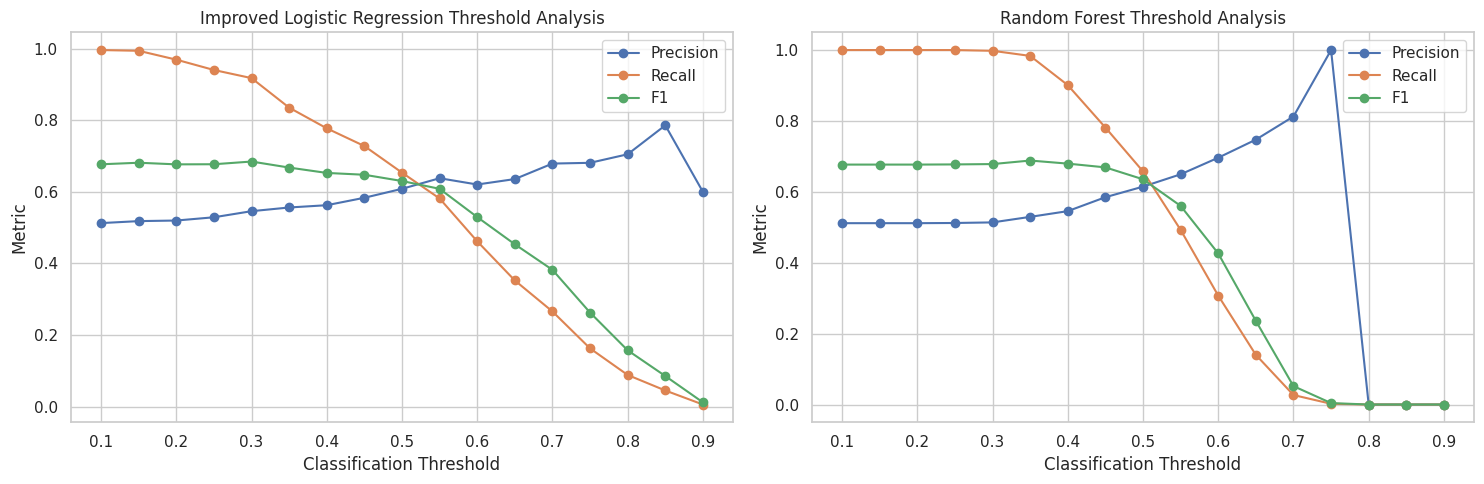

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(15, 5))
axes[0].plot(threshold_logistic["Threshold"],threshold_logistic["Precision"],marker="o",label="Precision")
axes[0].plot(threshold_logistic["Threshold"],threshold_logistic["Recall"],marker="o",label="Recall")
axes[0].plot(threshold_logistic["Threshold"],threshold_logistic["F1 Score"],marker="o",label="F1")
axes[0].set_title("Improved Logistic Regression Threshold Analysis")
axes[0].set_xlabel("Classification Threshold")
axes[0].set_ylabel("Metric")
axes[0].legend()
axes[1].plot(threshold_rf["Threshold"],threshold_rf["Precision"],marker="o",label="Precision")
axes[1].plot(threshold_rf["Threshold"],threshold_rf["Recall"],marker="o",label="Recall")
axes[1].plot(threshold_rf["Threshold"],threshold_rf["F1 Score"],marker="o",label="F1")
axes[1].set_title("Random Forest Threshold Analysis")
axes[1].set_xlabel("Classification Threshold")
axes[1].set_ylabel("Metric")
axes[1].legend()
plt.tight_layout()
plt.show()

Precison(Blue) rises as the threshold increases, while Recall(Orange) drops sharply because the model becomes more restrictive and misses true positive cases.
The F1-score(Green) measures the overall balance, showing that a threshold that is too strict severely reduces the model's overall effectiveness.

#**SELECT OPERATIONAL THRESHOLD**

In [ ]:
MINIMUM_RECALL = 0.60
eligible_thresholds = threshold_rf[threshold_rf["Recall"]>= MINIMUM_RECALL].copy()
if len(eligible_thresholds) > 0:
    selected_threshold_row = (eligible_thresholds.sort_values(["F1 Score","Recall"],ascending=False).iloc[0])
else:
    selected_threshold_row = (threshold_rf.sort_values("Recall",ascending=False).iloc[0])
selected_threshold = float(
    selected_threshold_row["Threshold"])
print("Provisional operational threshold:",selected_threshold)
display(selected_threshold_row.to_frame("Value"))

Provisional operational threshold: 0.35


,Value
Threshold,0.350000
Precision,0.529412
Recall,0.983505
F1 Score,0.688312
Accuracy,0.544304
No-Show Flags,901.000000


#**CANDIDATE MODEL WITH SELECTED THRESHOLD**

In [ ]:
candidate_predictions = (rf_probabilities>= selected_threshold).astype(int)
candidate_metrics = calculate_metrics("Random Forest — Selected Threshold",y_test_r,candidate_predictions,rf_probabilities)
candidate_metrics_health_connect = pd.DataFrame([candidate_metrics])
display(candidate_metrics_health_connect.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest — Selected Threshold,0.5443,0.5294,0.9835,0.6883,0.6565


#**CANDIDATE CONFUSION MATRIX**

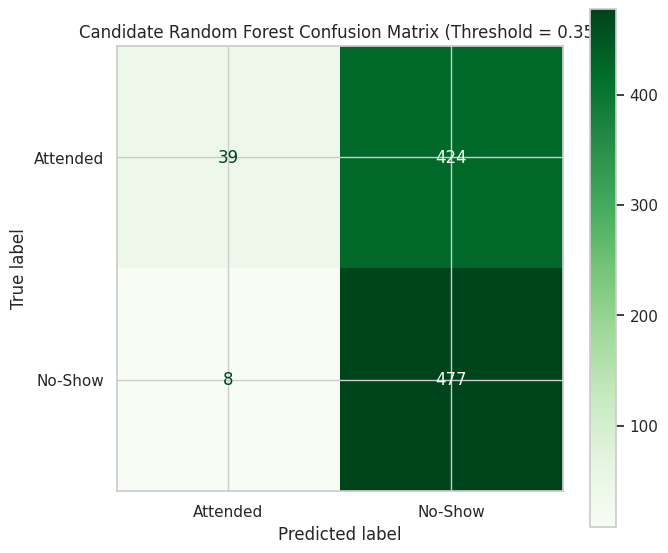

In [ ]:
candidate_cm = confusion_matrix(y_test_r,candidate_predictions)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=candidate_cm,display_labels=["Attended","No-Show"]).plot(ax=ax,cmap="Greens")
plt.title(f"Candidate Random Forest Confusion Matrix "f"(Threshold = {selected_threshold:.2f})")
plt.tight_layout()
plt.show()

The model successfully catches 477/485 actual no shows, meaning it misses almost nobody who skips an appointment. However, it creates 424 false alarms by predicting a no show for people who actually end up attending their appointment.

#**CANDIDATE ERROR ANALYSIS**

In [ ]:
candidate_error_analysis = X_test_r.copy()
candidate_error_analysis["actual_no_show"] = y_test_r.values
candidate_error_analysis["predicted_no_show"] = candidate_predictions
candidate_error_analysis["predicted_probability"] = rf_probabilities
candidate_error_analysis["prediction_type"] = candidate_error_analysis.apply(classify_prediction,axis=1)
candidate_error_summary = (candidate_error_analysis["prediction_type"].value_counts().to_frame("Count"))
candidate_error_summary["Percentage"] = (candidate_error_summary["Count"]/ len(candidate_error_analysis)* 100).round(2)
display(candidate_error_summary)

,Count,Percentage
prediction_type,,
True Positive,477,50.32
False Positive,424,44.73
True Negative,39,4.11
False Negative,8,0.84


#**ROC CURVES**

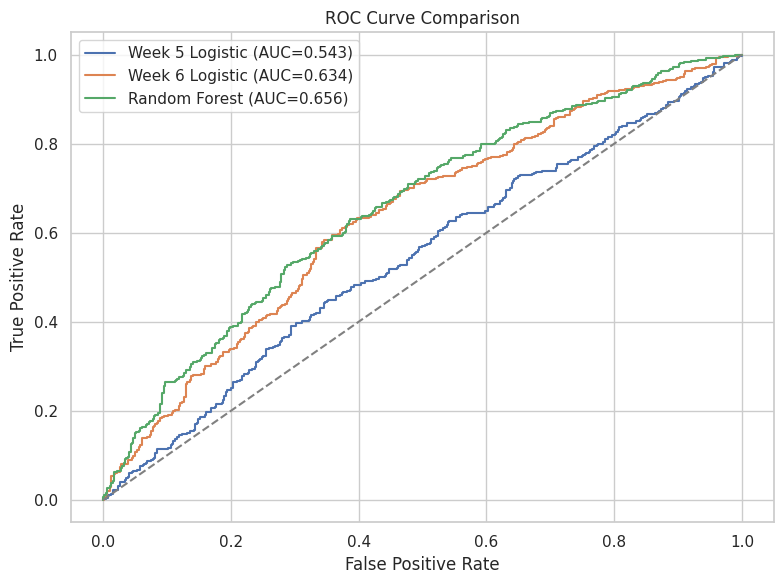

In [ ]:
baseline_fpr, baseline_tpr, _ = roc_curve(y_test,baseline_probabilities)
logistic_fpr, logistic_tpr, _ = roc_curve(y_test_r,improved_logistic_probabilities)
rf_fpr, rf_tpr, _ = roc_curve(y_test_r,rf_probabilities)
plt.figure(figsize=(8, 6))
plt.plot(baseline_fpr,baseline_tpr,label=f"Week 5 Logistic "f"(AUC={roc_auc_score(y_test, baseline_probabilities):.3f})")
plt.plot(logistic_fpr,logistic_tpr,label=f"Week 6 Logistic "f"(AUC={roc_auc_score(y_test_r, improved_logistic_probabilities):.3f})")
plt.plot(rf_fpr,rf_tpr,label=f"Random Forest "f"(AUC={roc_auc_score(y_test_r, rf_probabilities):.3f})")
plt.plot([0, 1],[0, 1],linestyle="--",color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

The Random Forest model is the most accurate overall, showing a clear improvement in telling who will show up versus who will miss an appointment.
The Week 6 Logistic model shows progress, outperforming the Week 5 version which was barely better than a random guess.

#**LOGISTIC REGRESSION COEFFICIENTS**

In [ ]:
fitted_refined_preprocessor = (improved_logistic.named_steps["preprocessor"])
fitted_refined_classifier = (improved_logistic.named_steps["classifier"])
refined_feature_names = (fitted_refined_preprocessor.get_feature_names_out())
refined_coefficients = (fitted_refined_classifier.coef_[0])
refined_coefficient_table = pd.DataFrame({"Feature": refined_feature_names,"Coefficient": refined_coefficients})
refined_coefficient_table["Absolute Coefficient"] = (refined_coefficient_table["Coefficient"].abs())
refined_coefficient_table = (refined_coefficient_table.sort_values("Absolute Coefficient",ascending=False))
display(refined_coefficient_table.head(20))

,Feature,Coefficient,Absolute Coefficient
262,categorical__appointment_date_2025-09-07,-1.410815,1.410815
426,categorical__appointment_date_2026-02-19,-1.303360,1.303360
370,categorical__appointment_date_2025-12-25,1.288073,1.288073
368,categorical__appointment_date_2025-12-23,1.265280,1.265280
443,categorical__appointment_date_2026-03-08,-1.264291,1.264291
517,categorical__appointment_date_2026-05-21,1.261078,1.261078
142,categorical__appointment_date_2025-05-10,-1.241851,1.241851
316,categorical__appointment_date_2025-11-01,-1.223525,1.223525
229,categorical__appointment_date_2025-08-05,-1.166111,1.166111
554,categorical__appointment_date_2026-06-27,-1.128451,1.128451


#**RANDOM FOREST FEATURE IMPORTANCE**

In [ ]:
rf_preprocessor = (random_forest.named_steps["preprocessor"])
rf_classifier = (random_forest.named_steps["classifier"])
rf_feature_names = (rf_preprocessor.get_feature_names_out())
rf_importances = (rf_classifier.feature_importances_)
rf_importance_table = pd.DataFrame({"Feature": rf_feature_names,"Importance": rf_importances})
rf_importance_table = (rf_importance_table.sort_values("Importance",ascending=False))
display(rf_importance_table.head(20))

,Feature,Importance
3,numeric__booking_lead_days,0.270021
4,numeric__distance_to_clinic_km,0.077571
0,numeric__Unnamed: 0,0.059574
5,numeric__age,0.054711
1,numeric__previous_no_shows,0.054511
2,numeric__waiting_time_minutes,0.050211
565,categorical__appointment_type_General Consulta...,0.010519
564,categorical__appointment_type_Follow-up,0.010335
567,categorical__gender_Female,0.009967
561,categorical__reminder_sent_No,0.009671


#**RANDOM FOREST FEATURE IMPORTANCE VISUALISATION**

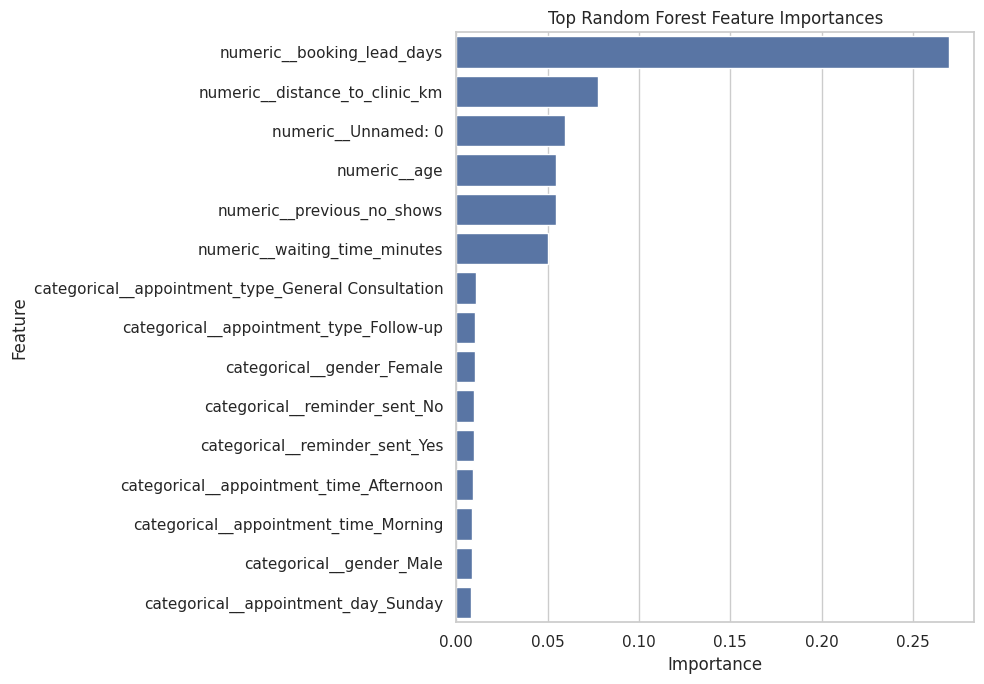

In [ ]:
top_rf_features = (rf_importance_table.head(15).sort_values("Importance", ascending= False))
plt.figure(figsize=(10, 7))
sns.barplot(data=top_rf_features,x="Importance",y="Feature")
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#**AUTOMATIC CANDIDATE MODEL SELECTION**

In [ ]:
selection_table = pd.DataFrame([{"Model":"Week 5 Logistic Regression","Recall":baseline_metrics["Recall"],"F1 Score":baseline_metrics["F1 Score"],"ROC-AUC":baseline_metrics["ROC-AUC"]},{"Model":"Week 6 Improved Logistic Regression","Recall":calculate_metrics("x",y_test_r,improved_logistic_predictions,improved_logistic_probabilities)["Recall"],"F1 Score":calculate_metrics("x",y_test_r,improved_logistic_predictions,improved_logistic_probabilities)["F1 Score"],"ROC-AUC":calculate_metrics("x",y_test_r,improved_logistic_predictions,improved_logistic_probabilities)["ROC-AUC"]},{"Model":"Week 6 Random Forest","Recall":candidate_metrics["Recall"],"F1 Score":candidate_metrics["F1 Score"],"ROC-AUC":candidate_metrics["ROC-AUC"]}])
selection_table = selection_table.sort_values(["Recall","F1 Score","ROC-AUC"],ascending=False)
display(selection_table.round(4))
candidate_model_name = (selection_table.iloc[0]["Model"])
print("Provisional candidate model:",candidate_model_name)

,Model,Recall,F1 Score,ROC-AUC
2,Week 6 Random Forest,0.9835,0.6883,0.6565
1,Week 6 Improved Logistic Regression,0.6536,0.6302,0.6344
0,Week 5 Logistic Regression,0.5010,0.5215,0.5434


Provisional candidate model: Week 6 Random Forest


#**WEEK 6 SUMMARY TABLE**

In [ ]:
week6_summary = pd.DataFrame({"Measure": ["Week 5 baseline model","Improved models evaluated","Cross-validation folds","Selected candidate threshold","Candidate model","Week 7 testing required"],"Result": ["Logistic Regression","Improved Logistic Regression + Random Forest","5-fold Stratified CV",selected_threshold,candidate_model_name,"Yes"]})
display(week6_summary)

,Measure,Result
0,Week 5 baseline model,Logistic Regression
1,Improved models evaluated,Improved Logistic Regression + Random Forest
2,Cross-validation folds,5-fold Stratified CV
3,Selected candidate threshold,0.35
4,Candidate model,Week 6 Random Forest
5,Week 7 testing required,Yes


#SAVING WEEK 6 OUTPUTS

In [ ]:
week6_model_results.to_csv("HealthConnect_Week6_Model_Comparison.csv",index=False)
cv_results.to_csv("HealthConnect_Week6_Cross_Validation.csv",index=False)
threshold_logistic.to_csv("HealthConnect_Week6_Logistic_Threshold_Analysis.csv",index=False)
threshold_rf.to_csv("HealthConnect_Week6_RandomForest_Threshold_Analysis.csv",index=False)
error_analysis.to_csv("HealthConnect_Week6_Baseline_Error_Analysis.csv",index=False)
candidate_error_analysis.to_csv("HealthConnect_Week6_Candidate_Error_Analysis.csv",index=False)
refined_coefficient_table.to_csv("HealthConnect_Week6_Logistic_Coefficients.csv",index=False)
rf_importance_table.to_csv("HealthConnect_Week6_RandomForest_Feature_Importance.csv",index=False)
week6_summary.to_csv("HealthConnect_Week6_Summary.csv",index=False)
print("=" * 70)
print("WEEK 6 OUTPUTS SAVED")

WEEK 6 OUTPUTS SAVED
